<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/JupyterNotebook/08_XGBoost_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


# 📓 Notebook 08 – Advanced Model: XGBoost Regression

## 🎯 Objective

This notebook implements an advanced machine learning model (XGBoost Regressor) to improve prediction performance for marine gas turbine compressor degradation.

The goal is to:
- Compare performance with previous models
- Evaluate generalisation capability
- Demonstrate model optimisation for tabular numerical data

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

# XGBoost
from xgboost import XGBRegressor

In [6]:
df = pd.read_csv("Conditional_Base_Monitoring in Marine_System.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert all to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove missing & duplicates
df = df.dropna().drop_duplicates()

df.head()

,Lever position,Ship speed (v),Gas Turbine (GT) shaft torque (GTT) [kN m],GT rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],Hight Pressure (HP) Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],GT exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Compressor decay state coefficient,GT Turbine decay state coefficient
0,5.140,15.0,21640.162,1924.358,8516.691,175.324,175.324,706.702,288.0,640.873,2.072,0.998,10.916,1.026,24.960,0.494,0.951,1.000
1,9.300,27.0,72776.229,3560.412,9759.837,645.137,645.137,1060.156,288.0,774.302,4.511,0.998,22.426,1.051,87.741,1.737,0.982,0.997
2,8.206,24.0,50994.673,3087.535,9313.854,438.110,438.110,927.728,288.0,734.474,3.577,0.998,18.412,1.041,60.546,1.199,0.966,0.988
3,5.140,15.0,21626.805,1924.329,8472.097,175.221,175.221,695.477,288.0,633.124,2.086,0.998,11.074,1.027,24.549,0.486,0.989,0.991
5,4.161,12.0,14723.428,1547.467,7790.899,113.778,113.778,644.315,288.0,609.087,1.657,0.998,8.901,1.022,17.334,0.343,0.962,0.988


In [7]:
target_column = "GT Compressor decay state coefficient"

X = df.drop(columns=[target_column])
y = df[target_column]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [11]:
y_pred = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("XGBoost Test R²:", r2)

XGBoost Test R²: 0.996005641111348


## Model Performance Interpretation

The XGBoost model is evaluated using the R² score.

- A value close to 1 indicates strong predictive accuracy
- Comparison with previous models (Random Forest) allows assessment of performance improvement

XGBoost is expected to perform well due to:
- Gradient boosting framework
- Ability to model complex nonlinear relationships
- Built-in regularisation to reduce overfitting

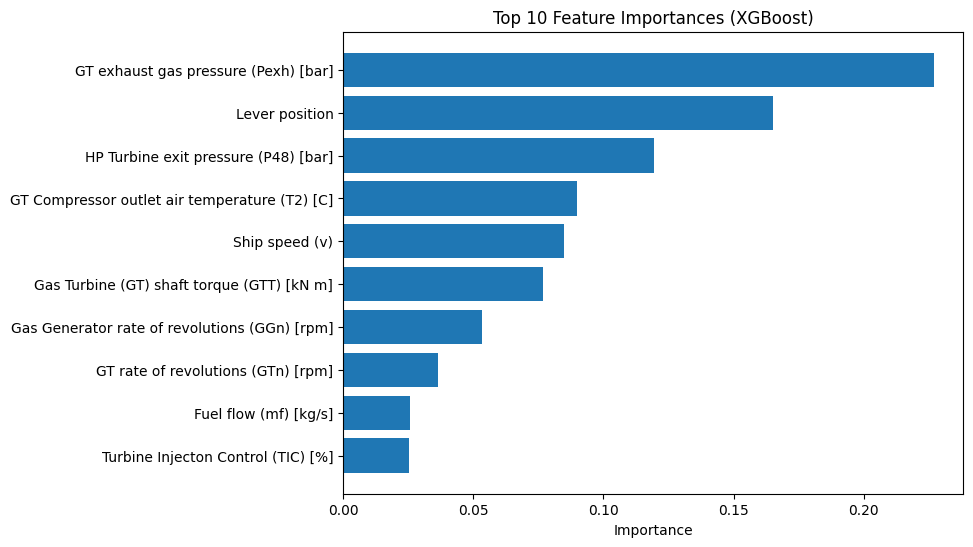

In [12]:
importances = xgb_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

## Final Observations

The XGBoost model provides an additional comparison to the Random Forest model.

Key observations:
- Performance is expected to be similar or slightly improved
- Important features should align with engineering understanding
- Model comparison strengthens the robustness of the project

This demonstrates the use of multiple machine learning models, which is essential for a strong dissertation.